# Mellinguer complete

# Mellinguer modified

# Mellinguer two drones

# With MPPI planner

# Single drone, TORCH, Z_ord sampler

# MPPI Single - Scheduler + ejecucion completa

Masa del dron: 0.39 kg
Posición inicial: [0. 0. 1.]
Tiempo de simulación (dt): 0.0100 s


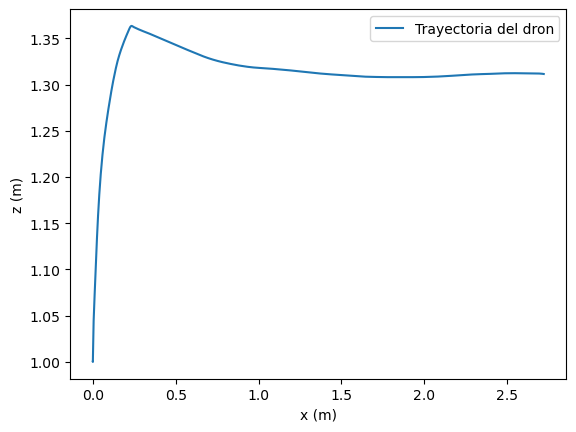

In [5]:
import time
import numpy as np
import mujoco
from mujoco import viewer
from mellinguer import MellinguerControllerForce
from MPPI import SingleMPPIPlanner, SingleMPPIPlannerTorch
from dynamics import SingleMassDynamicModel, SingleMassDynamicModelTorch
from helper import quat_to_rotmat, ForceArrow, enforce_tilt_and_thrust_limits

import os
# libiomp5md.dll, but found libiomp5md.dll already initialized. PROBLEM with OpenMP runtime!
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"  # UNSAFE workaround, only used for experimentation.


############ MuJoCo ##############
# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/single_quad_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# obtener arrow para visualizar fuerzas (opcional, requiere que tengas un plugin o función para esto)
arrow = ForceArrow(model, data, arrow_idx=1)

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

print(f"Masa del dron: {m:.2f} kg")
print(f"Posición inicial: {p0}")
print(f"Tiempo de simulación (dt): {dt:.4f} s")

############ MPPI Planner ##############

# IMPORTANTE: para hover necesitas Fz_max > m*9.81
Fxy = 8.0     # fuerza lateral máxima
Fz_min = 0.0          # típico en quad: no hay empuje negativo (ajusta si tu modelo sí)
Fz_max = 25.0   # fuerza vertical máxima (debe ser > m*9.81 para hover)

# Crear planner MPPI
planner = SingleMPPIPlannerTorch(
    dt=dt,
    horizon=40,            # pasos
    num_samples=4096,       # rollouts
    lambda_=10.0,            # temperatura
    noise_sigma=np.array([2.0*m, 2.0*m, 4.0*m]),  # ruido en newton step
    F_min=np.array([-Fxy, -Fxy, Fz_min]),
    F_max=np.array([Fxy, Fxy, Fz_max]),
    w_goal=6.0,
    w_terminal=50.0,
    w_F=0.03,
    w_smooth=0.02,
    w_obs=80.0,
    obs_margin=0.20,
    obs_softness=0.15,
    goal_tolerance=0.10,
    # altura
    z_min=1.0,
    z_max=1.5,
    z_margin=0.15,
    w_z=200.0,
    w_z_terminal=400.0,
    #velocidad
    v_max=5.0,
    v_margin=0.5,
    w_v=100.0,
    w_v_terminal=200.0,
    rng_seed=0,
    device="cuda")

# model dynamics mass model
mass_model = SingleMassDynamicModelTorch(dt=dt, mass=m, device="cuda")
planner.define_model(mass_model) # define modelo dinámico para MPPI

# Punto B (goal): ejemplo
goal = p0 + np.array([2.5, 0.0, 1.0])
planner.set_goal(goal)

# Obstáculos (deben coincidir con el XML)
obstacles = [
    {"type":"sphere", "c":[1.0,  0.0, 1.0], "r":0.25},
    {"type":"box",    "c":[1.6,  0.4, 1.0], "h":[0.20, 0.20, 0.40]},
    {"type":"box",    "c":[1.6, -0.4, 1.0], "h":[0.20, 0.20, 0.40]},
]
planner.set_obstacles(obstacles)


############# Mellinguer Controller ##################
# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerControllerForce(mass=m, gravity=9.81, gains=gains)

# Actuadores por nombre (para evitar depender del orden en el XML):
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")



################################################################################
##############################    SIMULACION    ################################
################################################################################

# guardar para debug/visualización
vector_r = []

# scheduler para MPPI
# mppi_every = 1 # ya esta antes de crear el planner, pero lo dejo aquí para referencia
# mppi_every = 5            # MPPI cada 5 steps (ajusta)
# F_des = np.array([0.0, 0.0, m*9.81], dtype=float)  # inicial hover
# step_count = 0

# buffer para plan MPPI
mppi_every = 1            # MPPI cada 5 steps
plan_idx = mppi_every     # fuerza a planificar al inicio
F_plan = None             # buffer (H,3)

# fallback hover por si aún no hay plan
F_fallback = np.array([0.0, 0.0, m*9.81], dtype=float)

with viewer.launch_passive(model, data) as vis:
    yaw_d = 0.0  # yaw objetivo fijo
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado real en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # guardar para debug/visualización
        vector_r.append(r)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        v_world = cvel[3:6]

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # ---------------------------
        # (2) MPPI: fuerza deseada en mundo (CON SCHEDULER)
        # ---------------------------
        
        # (A) Replan cada mppi_every steps
        if plan_idx >= mppi_every or F_plan is None: # si es hora de replanificar o no hay plan
            F0, _, _, F_seq = planner.compute_action(r, v_world)  # F_seq: (H,3)
            F_plan = F_seq # guarda el plan completo
            plan_idx = 0 # reset del plan_idx para ejecutar desde el inicio del nuevo plan

        # (B) Ejecuta el siguiente comando del plan
        if plan_idx < len(F_plan): # si el plan_idx está dentro del horizonte planificado
            F_des = F_plan[plan_idx] # toma la fuerza deseada del plan en el paso actual
        else: # si por alguna razón el plan_idx se salió del rango (debería ser raro), usa fallback
            F_des = F_fallback # fallback (hover) si algo salió mal con el plan

        plan_idx += 1 # incrementa el plan_idx para el próximo paso

        # seguridad: si tienes empuje negativo en Z
        F_des = F_des.copy()
        F_des[2] = max(F_des[2], 0.0)

        # límites realizables del quad (ajusta a tu XML)
        tilt_max = np.deg2rad(35.0)
        u1_max = 4.0 * Fz_max
        F_des = enforce_tilt_and_thrust_limits(F_des, u1_max=u1_max, tilt_max_rad=tilt_max)
        

        # visualizar fuerza deseada (opcional, requiere función/objeto para esto)
        arrow.update_force_arrow_mocap(
            p0_world=r,          # origen en el centro del dron
            F_world=F_des,       # fuerza MPPI en world
            scale=0.03,
            max_len=0.8,
            radius=0.01)

        # ---------------------------
        # (3) Mellinger attitude: u = [u1, u2, u3, u4]
        # ---------------------------
        u = controller.step(F_des, R, omega_body, psi_T=yaw_d)

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = float(u[0])
        data.ctrl[act_u2] = float(u[1])
        data.ctrl[act_u3] = float(u[2])
        data.ctrl[act_u4] = float(u[3])

        # ---------------------------
        # (5) Step MuJoCo
        # ---------------------------
        start = time.time()
        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        # # sincronizar en tiempo real
        # elapsed = time.time() - start
        # sleep_time = dt - elapsed
        # if sleep_time > 0:
        #     time.sleep(sleep_time)

# visualización de trayectoria (opcional)
import matplotlib.pyplot as plt
vector_r = np.array(vector_r)
plt.figure()
plt.plot(vector_r[:,0], vector_r[:,2], label='Trayectoria del dron')
plt.xlabel('x (m)')
plt.ylabel('z (m)')

#ajustar límites y agregar referencia deseada
# plt.xlim(p0[0] - 1, p0[0] + 1)
# plt.ylim(p0[2] - 1, p0[2] + 1)

plt.legend()
plt.show()



# SVGP

# SVGP RAW

dt: 0.0100  mass: 0.394 kg  p0: [0. 0. 1.]
[LOAD] model: D:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_fixed\logs\svgp_dyn.pt
[LOAD] rollouts: D:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_fixed\logs\rollouts_all.npz

=== EPISODE 1/10 ===
goal: [2.5 0.  2. ]


 29%|██▉       | 441/1500 [01:03<02:32,  6.96it/s]

Viewer closed.


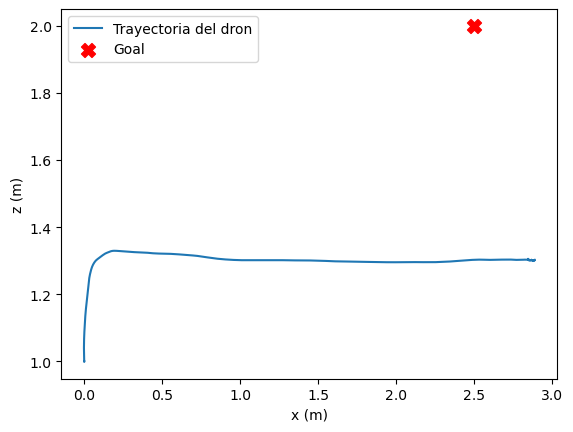

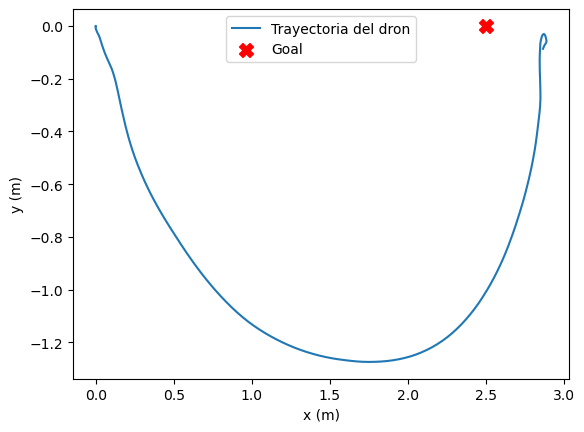

In [6]:
import os
import time
import numpy as np
import mujoco
from mujoco import viewer

from mellinguer import MellinguerControllerForce
from MPPI import SingleMPPIPlannerTorch
from helper import quat_to_rotmat, ForceArrow, enforce_tilt_and_thrust_limits, get_drone_state, set_goal_for_episode, reset_episode
from dynamics import SingleMassDynamicModelTorch, SVGPDroneDynamicModel
import tqdm


# libiomp5md.dll, but found libiomp5md.dll already initialized. PROBLEM with OpenMP runtime!
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"  # UNSAFE workaround, only used for experimentation.

# ============================================================
# --------- 1) CONFIGURACIÓN MUJOCO --------------------------
# ============================================================
# XML_PATH = "system/single_quad_obs_u1234.xml"
XML_PATH = "D:\\Lehigh\\1st Semester\\Indepedent Study\\Code\\RL-Rod-Project\\model_based_fixed\\system\\single_quad_obs_u1234.xml"
# Episodios
NUM_EPISODES = 10 # Episodios
STEPS_PER_EP = 1500

# Render
RENDER = True

# Paths persistencia
LOG_DIR = "D:\\Lehigh\\1st Semester\\Indepedent Study\\Code\\RL-Rod-Project\\model_based_fixed\\logs"
MODEL_PATH = os.path.join(LOG_DIR, "svgp_dyn.pt")
ROLLOUTS_PATH = os.path.join(LOG_DIR, "rollouts_all.npz")
EP_ROLLOUTS_FMT = os.path.join(LOG_DIR, "rollouts_ep{:03d}.npz")

os.makedirs(LOG_DIR, exist_ok=True)

# MPPI scheduler
MPPI_EVERY = 1

# MPPI plan fallback
YAW_TARGET = 0.0

# Si quieres que el GP se resetee cada episodio (empezar de cero):
RESET_GP_EACH_EP = False

# Guardar cada episodio
SAVE_EACH_EP = False

# Guardar y entrenar modelo final al terminar todos los episodios
SAVE_FINAL = False

# Dybamics model para MPPI: puedes usar punto-masa o el GP cuando ya esté entrenado
DYN_MODEL_TYPE = "GP"  # opciones: "MASS" o "GP"

# ============================================================
#                 HELPERS
# ============================================================
#-----------\ import helpers
# from helper import quat_to_rotmat, ForceArrow, enforce_tilt_and_thrust_limits, get_drone_state, set_goal_for_episode


# ============================================================
#                      MAIN
# ============================================================
def main():
    # ============================================================
    # --------- 1) CONFIGURACIÓN MUJOCO --------------------------
    # ============================================================
    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data = mujoco.MjData(model)
    dt = model.opt.timestep

    drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
    if drone_id < 0:
        raise ValueError("No existe el body 'drone_3d' en el XML.")

    mujoco.mj_forward(model, data)
    p0 = data.xpos[drone_id].copy()
    m = float(model.body_subtreemass[drone_id])

    print(f"dt: {dt:.4f}  mass: {m:.3f} kg  p0: {p0}")

    # actuadores
    act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
    act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
    act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
    act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
    if min(act_u1, act_u2, act_u3, act_u4) < 0:
        raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")

    arrow = ForceArrow(model, data, arrow_idx=1) if RENDER else None

    # ============================================================
    # --------- 2) Mellinguer Controller -------------------------
    # ============================================================
    gains = [
        np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
        np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
        np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
        np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
    ]
    controller = MellinguerControllerForce(mass=m, gravity=9.81, gains=gains)

    # ============================================================
    # --------- 3) GP dynamics model (learn online) --------------
    # ============================================================
    dyn_gp = SVGPDroneDynamicModel(
        dt=dt,
        mass=m,
        gravity=9.81,
        device="cuda",
        kernel="RBF",
        lr=0.01,
        batch_size=256,
        num_inducing=2**5,  # puedes ajustar según tu GPU, más inducing points = modelo más preciso pero más lento
        init_train_steps=800, # pasos iniciales para llenar el buffer antes de entrenar la primera vez
        train_every=20,          # entrenar cada N steps (ajusta, más frecuencia = modelo más actualizado pero más tiempo de cómputo)
        online_steps=50,         # grad steps online (puedes ajustar, más pasos = modelo más actualizado pero más tiempo de cómputo)
        min_points_to_train=300, # mínimo de puntos en el buffer para empezar a entrenar (ajusta, si es muy bajo puede ser inestable, si es muy alto tarda más en empezar a mejorar)
        reset_each_episode=RESET_GP_EACH_EP, # si True, el modelo se reseteará cada episodio (útil para probar aprendizaje desde cero cada vez, pero si quieres acumular experiencia a lo largo de episodios, déjalo en False
    )

    # cargar modelo si existe
    if os.path.exists(MODEL_PATH):
        print(f"[LOAD] model: {MODEL_PATH}")
        dyn_gp.load_model(MODEL_PATH)

    # cargar rollouts si existe
    if os.path.exists(ROLLOUTS_PATH):
        print(f"[LOAD] rollouts: {ROLLOUTS_PATH}")
        dyn_gp.load_rollouts(ROLLOUTS_PATH, append=True)
        # si cargaste datos y no está entrenado, puedes entrenar full
        if not getattr(dyn_gp, "_trained_once", False):
            print("[TRAIN] full from loaded rollouts...")
            dyn_gp.train_full()

    # ============================================================
    # --------- 4) MPPI Planner ----------------------------------
    # ============================================================
    # límites MPPI (fuerza total en WORLD)
    Fxy = 8.0 * m
    Fz_min = 0.0
    Fz_max = 25.0 * m

    planner = SingleMPPIPlannerTorch(
        dt=dt,
        horizon=50,            # pasos
        num_samples=1024//2,       # rollouts
        lambda_=10.0,            # temperatura
        noise_sigma=np.array([2.0*m, 2.0*m, 4.0*m]),  # ruido en newton step
        F_min=np.array([-Fxy, -Fxy, Fz_min]),
        F_max=np.array([Fxy, Fxy, Fz_max]),
        w_goal=6.0,
        w_terminal=50.0,
        w_F=0.03,
        w_smooth=0.02,
        w_obs=80.0,
        obs_margin=0.20,
        obs_softness=0.15,
        goal_tolerance=0.10,
        # altura
        z_min=1.0,
        z_max=1.5,
        z_margin=0.15,
        w_z=200.0,
        w_z_terminal=400.0,
        #velocidad
        v_max=5.0,
        v_margin=0.5,
        w_v=100.0,
        w_v_terminal=200.0,
        rng_seed=0,
        device="cuda")

    # modelo dinámico para MPPI: puedes usar punto-masa o el GP cuando ya esté entrenado
    if DYN_MODEL_TYPE == "GP": # si quieres usar el GP desde el inicio (puede ser inestable al principio, pero es para probar)
         mass_model = SVGPDroneDynamicModel(dt=dt, mass=m, device="cuda")
         mass_model.load_model(MODEL_PATH)  # carga el modelo entrenado (si existe)
    elif DYN_MODEL_TYPE == "MASS": # si quieres usar un modelo de punto-masa simple al inicio
         mass_model = SingleMassDynamicModelTorch(dt=dt, mass=m, device="cuda")
    else:
        raise ValueError(f"DYN_MODEL_TYPE desconocido: {DYN_MODEL_TYPE}")

    planner.define_model(mass_model)

    # obstáculos (ejemplo)
    obstacles = [
        {"type": "sphere", "c": [1.0,  0.0, 1.0], "r": 0.25},
        {"type": "box",   "c": [1.6,  0.4, 1.0], "h": [0.20, 0.20, 0.40]},
        {"type": "box",   "c": [1.6, -0.4, 1.0], "h": [0.20, 0.20, 0.40]},
    ]
    planner.set_obstacles(obstacles)


    vector_r = []

    def run_episodes(vis=None):
        nonlocal p0

        for ep in range(NUM_EPISODES):
            print(f"\n=== EPISODE {ep+1}/{NUM_EPISODES} ===")

            # reset sim
            reset_episode(model, data)
            # mujoco.mj_resetData(model, data)
            # mujoco.mj_forward(model, data)
            # p0 = data.xpos[drone_id].copy()

            # reset episode (GP buffers, optionally model)
            dyn_gp.reset_episode(clear_buffers=False) # si clear_buffers=True, se borra el buffer de rollouts del GP cada episodio, si False, se mantiene (útil para acumular datos a lo largo de episodios)

            # set goal per episode
            goal = set_goal_for_episode(p0, ep)
            planner.set_goal(goal)

            print(f"goal: {goal}")
            

            # MPPI plan buffer
            plan_idx = MPPI_EVERY
            F_plan = None
            F_fallback = np.array([0.0, 0.0, m * 9.81], dtype=float)

            # safety limits for realizability
            tilt_max = np.deg2rad(35.0)
            u1_max = Fz_max  # thrust total max coherente con F_des (N)

            for step in tqdm.tqdm(range(STEPS_PER_EP)):
                if vis is not None and not vis.is_running():
                    print("Viewer closed.")
                    return

                # (1) read state
                r, v_world, R, omega_body = get_drone_state(model, data, drone_id)
                vector_r.append(r) # save for visualization

                # (2) MPPI (replan each MPPI_EVERY)
                if plan_idx >= MPPI_EVERY or F_plan is None:
                    F0, _, _, F_seq = planner.compute_action(r, v_world)
                    F_plan = F_seq
                    plan_idx = 0

                if plan_idx < len(F_plan):
                    F_des = F_plan[plan_idx].copy()
                else:
                    F_des = F_fallback.copy()
                plan_idx += 1

                # Z no negativa
                F_des[2] = max(F_des[2], 0.0)

                # cerca del goal => hover + damping para no caer
                if np.linalg.norm(r - goal) < planner.goal_tolerance:
                    F_des = np.array([0.0, 0.0, m * 9.81]) - np.array([2.0, 2.0, 3.0]) * v_world

                # realizable
                F_des = enforce_tilt_and_thrust_limits(F_des, u1_max=u1_max, tilt_max_rad=tilt_max)

                # (optional) draw desired force
                if arrow is not None:
                    arrow.update_force_arrow_mocap(
                        p0_world=r,
                        F_world=F_des,
                        scale=0.03,
                        max_len=0.8,
                        radius=0.01,
                    )

                # (3) low-level controller
                u = controller.step(F_des, R, omega_body, psi_T=YAW_TARGET)

                # (4) apply to actuators
                data.ctrl[act_u1] = float(u[0])
                data.ctrl[act_u2] = float(u[1])
                data.ctrl[act_u3] = float(u[2])
                data.ctrl[act_u4] = float(u[3])

                # ---- collect transition for GP ----
                pos0 = r.copy()
                vel0 = v_world.copy()
                F0 = F_des.copy()

                # (5) sim step
                mujoco.mj_step(model, data)

                # new state
                r2, v2_world, _, _ = get_drone_state(model, data, drone_id)

                # online add + (optional) online train each N steps
                # agrega la transición al buffer del GP, y si train_online=True, entrena cada online_steps pasos (ajusta en la configuración del modelo)
                dyn_gp.add_transition(pos0, vel0, F0, r2, v2_world, train_online=False) # si train_online=True, se entrena cada online_steps pasos (ajusta en la configuración del modelo)

                if vis is not None:
                    vis.sync()

            # end episode: train a bit more + save
            print(f"[EP {ep}] steps collected: {len(dyn_gp.Z_buf)}")

            # # opcional: un entrenamiento final del episodio
            # dyn_gp.train_online(steps=200)

            if SAVE_EACH_EP:
                ep_path = EP_ROLLOUTS_FMT.format(ep)
                dyn_gp.save_rollouts(ep_path)
                print(f"[SAVE] episode rollouts: {ep_path}")

                # append + save global rollouts
                # (guardamos buffer del episodio en un archivo global acumulado)
                if os.path.exists(ROLLOUTS_PATH):
                    # cargar y re-guardar acumulado (simple y robusto)
                    tmp = SVGPDroneDynamicModel(dt=dt, mass=m, device="cuda")
                    tmp.load_rollouts(ROLLOUTS_PATH, append=False)
                    tmp.load_rollouts(ep_path, append=True)
                    tmp.save_rollouts(ROLLOUTS_PATH)
                else:
                    dyn_gp.save_rollouts(ROLLOUTS_PATH)

                dyn_gp.save_model(MODEL_PATH)
                print(f"[SAVE] model: {MODEL_PATH}")
                print(f"[SAVE] rollouts_all: {ROLLOUTS_PATH}")

        # fin de todos los episodios: entrenar full y guardar
        if SAVE_FINAL:
            print("\n[FINAL TRAIN] training full on all collected data...")
            # print size of collected data
            print(f"total collected transitions: {len(dyn_gp.Z_buf)}")
            dyn_gp.train_full()
            dyn_gp.save_model(os.path.join(LOG_DIR, "svgp_dyn.pt"))
            dyn_gp.save_rollouts(os.path.join(LOG_DIR, "rollouts_all.npz"))

    if RENDER:
        with viewer.launch_passive(model, data) as vis:
            run_episodes(vis=vis)
    else:
        run_episodes(vis=None)

    
    # opcional: visualización de trayectoria final
    # NEEDS TO DEFINE vector_r = [] and append states to it durante la simulación para esto funcione (ejemplo: vector_r.append(r) después de leer el estado)
    
    import matplotlib.pyplot as plt
    vector_r = np.array(vector_r)
    goal = planner.goal.cpu().numpy()

    plt.figure()
    plt.plot(vector_r[:,0], vector_r[:,2], label='Trayectoria del dron')
    plt.scatter(goal[0], goal[2], color='red', label='Goal', marker='X', s=100)
    plt.xlabel('x (m)')
    plt.ylabel('z (m)')
    plt.legend()
    plt.show()
    plt.figure()
    plt.plot(vector_r[:,0], vector_r[:,1], label='Trayectoria del dron')
    plt.scatter(goal[0], goal[1], color='red', label='Goal', marker='X', s=100)
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()

# 2Quat SVGP

In [9]:
import os
import numpy as np
import mujoco
from mujoco import viewer
import tqdm

from mellinguer import MellinguerControllerForce
from MPPI import DoubleMPPIPlannerTorch
from helper import ForceArrow, enforce_tilt_and_thrust_limits, get_drone_state, reset_episode, set_goal_for_episode
from dynamics import SVGPDoubleDroneDynamicModel

# OpenMP workaround (Windows)
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

# ============================================================
# CONFIG
# ============================================================
XML_PATH = "D:\\Lehigh\\1st Semester\\Indepedent Study\\Code\\RL-Rod-Project\\model_based_fixed\\system\\2_quad_flexrod_obs_u1234.xml"

NUM_EPISODES = 10
STEPS_PER_EP = 1500
RENDER = True

LOG_DIR = "D:\\Lehigh\\1st Semester\\Indepedent Study\\Code\\RL-Rod-Project\\model_based_fixed\\logs_2drones"
MODEL_PATH = os.path.join(LOG_DIR, "svgp_dyn_2drones.pt")
ROLLOUTS_PATH = os.path.join(LOG_DIR, "rollouts_all_2drones.npz")
EP_ROLLOUTS_FMT = os.path.join(LOG_DIR, "rollouts_ep{:03d}_2drones.npz")
os.makedirs(LOG_DIR, exist_ok=True)

MPPI_EVERY = 1
YAW_TARGET_1 = 0.0
YAW_TARGET_2 = 0.0

RESET_GP_EACH_EP = False
SAVE_EACH_EP = False
SAVE_FINAL = False

# "GP" usa el GP (con fallback interno a point-mass si no está entrenado)
DYN_MODEL_TYPE = "GP"  # "GP" o "MASS" (MASS aquí lo dejo usando fallback del propio GP)


def main():
    # ---------------- MuJoCo ----------------
    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data = mujoco.MjData(model)
    dt = model.opt.timestep

    # Bodies (según tu XML 2_quad_flexrod_obs_u1234.xml)
    drone_id_1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "core_1")
    drone_id_2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "core_2")
    if drone_id_1 < 0 or drone_id_2 < 0:
        raise ValueError("No encontré bodies 'core_1' y/o 'core_2' en el XML.")

    mujoco.mj_forward(model, data)
    p0_1 = data.xpos[drone_id_1].copy()
    p0_2 = data.xpos[drone_id_2].copy()

    m1 = float(model.body_subtreemass[drone_id_1])
    m2 = float(model.body_subtreemass[drone_id_2])

    print(f"dt={dt:.4f}  m1={m1:.3f}  m2={m2:.3f}  p0_1={p0_1}  p0_2={p0_2}")

    # ---------------- actuators ----------------
    def aid(name: str) -> int:
        idx = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, name)
        if idx < 0:
            raise ValueError(f"No encontré actuator '{name}' en el XML.")
        return idx

    act = {
        "u1_1": aid("u1_thrust_1"), "u2_1": aid("u2_tau_x_1"), "u3_1": aid("u3_tau_y_1"), "u4_1": aid("u4_tau_z_1"),
        "u1_2": aid("u1_thrust_2"), "u2_2": aid("u2_tau_x_2"), "u3_2": aid("u3_tau_y_2"), "u4_2": aid("u4_tau_z_2"),
    }

    arrow1 = ForceArrow(model, data, arrow_idx=1) if RENDER else None
    arrow2 = ForceArrow(model, data, arrow_idx=2) if RENDER else None

    # ---------------- controllers ----------------
    gains = [
        np.array([5.0, 5.0, 10.0]),
        np.array([3.0, 3.0, 6.0]),
        np.array([8.0, 8.0, 2.0]),
        np.array([0.2, 0.2, 0.1]),
    ]
    ctrl1 = MellinguerControllerForce(mass=m1, gravity=9.81, gains=gains)
    ctrl2 = MellinguerControllerForce(mass=m2, gravity=9.81, gains=gains)

    # ---------------- GP dynamics model (2 drones) ----------------
    dyn_gp = SVGPDoubleDroneDynamicModel(
        dt=dt,
        mass1=m1,
        mass2=m2,
        gravity=9.81,
        device="cuda",
        kernel="RBF",
        lr=0.01,
        batch_size=256,
        num_inducing=256,
        init_train_steps=800,
        train_every=20,
        online_steps=50,
        min_points_to_train=300,
        reset_each_episode=RESET_GP_EACH_EP,
        predict_variance=False,   # <- importante para que no calcule var (más rápido)
    )

    # cargar modelo si existe
    if os.path.exists(MODEL_PATH):
        print(f"[LOAD] model: {MODEL_PATH}")
        dyn_gp.load_model(MODEL_PATH)

    # cargar rollouts si existe
    if os.path.exists(ROLLOUTS_PATH):
        print(f"[LOAD] rollouts: {ROLLOUTS_PATH}")
        dyn_gp.load_rollouts(ROLLOUTS_PATH, append=True)
        if not getattr(dyn_gp, "_trained_once", False):
            print("[TRAIN] full from loaded rollouts...")
            dyn_gp.train_full()

    # ---------------- MPPI (2 drones) ----------------
    Fxy1 = 8.0 * m1
    Fxy2 = 8.0 * m2
    Fz_min1, Fz_max1 = 0.0, 25.0 * m1
    Fz_min2, Fz_max2 = 0.0, 25.0 * m2

    U_min = np.array([-Fxy1, -Fxy1, Fz_min1,   -Fxy2, -Fxy2, Fz_min2], dtype=float)
    U_max = np.array([ Fxy1,  Fxy1, Fz_max1,    Fxy2,  Fxy2, Fz_max2], dtype=float)

    noise_sigma = np.array([2.0*m1, 2.0*m1, 4.0*m1,   2.0*m2, 2.0*m2, 4.0*m2], dtype=float)

    planner = DoubleMPPIPlannerTorch(
        dt=dt,
        horizon=40,
        num_samples=1024//2,
        lambda_=10.0,
        noise_sigma=noise_sigma,
        U_min=U_min,
        U_max=U_max,
        w_goal=6.0,
        w_terminal=50.0,
        w_u=0.03,
        w_smooth=0.02,
        w_obs=80.0,
        obs_margin=0.20,
        obs_softness=0.15,
        # altura/velocidad
        z_min=1.0, z_max=1.5, z_margin=0.15, w_z=200.0, w_z_terminal=400.0,
        v_max=5.0, v_margin=0.5, w_v=100.0, w_v_terminal=200.0,
        # separación
        w_sep=80.0, sep_min=0.45, sep_softness=0.10,
        rng_seed=0,
        device="cuda",
    )

    if DYN_MODEL_TYPE in ("GP", "MASS"):
        planner.define_model(dyn_gp)  # usa GP double (tiene fallback interno)
    else:
        raise ValueError(f"DYN_MODEL_TYPE desconocido: {DYN_MODEL_TYPE}")

    obstacles = [
        {"type": "sphere", "c": [1.0,  0.0, 1.0], "r": 0.25},
        {"type": "box",   "c": [1.6,  0.4, 1.0], "h": [0.20, 0.20, 0.40]},
        {"type": "box",   "c": [1.6, -0.4, 1.0], "h": [0.20, 0.20, 0.40]},
    ]
    planner.set_obstacles(obstacles)

    # ---------------- run episodes ----------------
    def run_episodes(vis=None):
        nonlocal p0_1, p0_2

        for ep in range(NUM_EPISODES):
            print(f"\n=== EPISODE {ep+1}/{NUM_EPISODES} ===")

            reset_episode(model, data)
            mujoco.mj_forward(model, data)

            p0_1 = data.xpos[drone_id_1].copy()
            p0_2 = data.xpos[drone_id_2].copy()

            dyn_gp.reset_episode(clear_buffers=False)

            goal1 = set_goal_for_episode(p0_1, ep)
            goal2 = set_goal_for_episode(p0_2, ep)
            planner.set_goals(goal1, goal2)
            print(f"goals: g1={goal1}, g2={goal2}")

            plan_idx = MPPI_EVERY
            U_plan = None

            F_hover_1 = np.array([0.0, 0.0, m1 * 9.81], dtype=float)
            F_hover_2 = np.array([0.0, 0.0, m2 * 9.81], dtype=float)
            U_fallback = np.concatenate([F_hover_1, F_hover_2], axis=0)

            tilt_max = np.deg2rad(35.0)

            for _step in tqdm.tqdm(range(STEPS_PER_EP)):
                if vis is not None and not vis.is_running():
                    print("Viewer closed.")
                    return

                r1, v1, R1, omega1 = get_drone_state(model, data, drone_id_1)
                r2, v2, R2, omega2 = get_drone_state(model, data, drone_id_2)
                X0 = np.concatenate([r1, v1, r2, v2], axis=0)  # (12,)

                if plan_idx >= MPPI_EVERY or U_plan is None:
                    U0, _X1_pred, U_seq = planner.compute_action(X0)
                    U_plan = U_seq
                    plan_idx = 0

                U_des = U_plan[plan_idx].copy() if plan_idx < len(U_plan) else U_fallback.copy()
                plan_idx += 1

                F1 = U_des[0:3].copy()
                F2 = U_des[3:6].copy()

                F1[2] = max(F1[2], 0.0)
                F2[2] = max(F2[2], 0.0)

                F1 = enforce_tilt_and_thrust_limits(F1, u1_max=Fz_max1, tilt_max_rad=tilt_max)
                F2 = enforce_tilt_and_thrust_limits(F2, u1_max=Fz_max2, tilt_max_rad=tilt_max)

                if arrow1 is not None:
                    arrow1.update_force_arrow_mocap(p0_world=r1, F_world=F1, scale=0.03, max_len=0.8, radius=0.01)
                if arrow2 is not None:
                    arrow2.update_force_arrow_mocap(p0_world=r2, F_world=F2, scale=0.03, max_len=0.8, radius=0.01)

                u1 = ctrl1.step(F1, R1, omega1, psi_T=YAW_TARGET_1)
                u2 = ctrl2.step(F2, R2, omega2, psi_T=YAW_TARGET_2)

                data.ctrl[act["u1_1"]] = float(u1[0])
                data.ctrl[act["u2_1"]] = float(u1[1])
                data.ctrl[act["u3_1"]] = float(u1[2])
                data.ctrl[act["u4_1"]] = float(u1[3])

                data.ctrl[act["u1_2"]] = float(u2[0])
                data.ctrl[act["u2_2"]] = float(u2[1])
                data.ctrl[act["u3_2"]] = float(u2[2])
                data.ctrl[act["u4_2"]] = float(u2[3])

                # transición (antes de step)
                p1_0, v1_0 = r1.copy(), v1.copy()
                p2_0, v2_0 = r2.copy(), v2.copy()

                mujoco.mj_step(model, data)

                r1n, v1n, _, _ = get_drone_state(model, data, drone_id_1)
                r2n, v2n, _, _ = get_drone_state(model, data, drone_id_2)

                dyn_gp.add_transition(
                    p1_0, v1_0, p2_0, v2_0,
                    F1, F2,
                    r1n, v1n, r2n, v2n,
                    train_online=False,
                )

                if vis is not None:
                    vis.sync()

            print(f"[EP {ep}] collected transitions total: {len(dyn_gp.Z_buf)}")

            if SAVE_EACH_EP:
                ep_path = EP_ROLLOUTS_FMT.format(ep)
                dyn_gp.save_rollouts(ep_path)
                print(f"[SAVE] episode rollouts: {ep_path}")

                dyn_gp.save_model(MODEL_PATH)
                print(f"[SAVE] model: {MODEL_PATH}")

    # run
    if RENDER:
        with viewer.launch_passive(model, data) as vis:
            run_episodes(vis)
    else:
        run_episodes(None)

    # final train/save
    if SAVE_FINAL:
        print("\n[FINAL TRAIN] training full on all collected data...")
        print(f"total transitions: {len(dyn_gp.Z_buf)}")
        dyn_gp.train_full()
        dyn_gp.save_model(MODEL_PATH)
        dyn_gp.save_rollouts(ROLLOUTS_PATH)
        print(f"[SAVE] model: {MODEL_PATH}")
        print(f"[SAVE] rollouts: {ROLLOUTS_PATH}")


if __name__ == "__main__":
    main()

dt=0.0100  m1=0.180  m2=0.180  p0_1=[-1.5  0.   0.2]  p0_2=[-0.3  0.   0.2]
[LOAD] model: D:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_fixed\logs_2drones\svgp_dyn_2drones.pt
[LOAD] rollouts: D:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_fixed\logs_2drones\rollouts_all_2drones.npz

=== EPISODE 1/10 ===
goals: g1=[1.  0.  1.2], g2=[2.2 0.  1.2]


100%|██████████| 1500/1500 [04:40<00:00,  5.35it/s]


[EP 0] collected transitions total: 16500

=== EPISODE 2/10 ===
goals: g1=[1.  0.8 1.2], g2=[2.2 0.8 1.2]


  9%|▉         | 135/1500 [00:25<04:16,  5.33it/s]

Viewer closed.


# Two Drones with Multi MPPI Planner

# Three Drones with Multi MPPI Planner

# Two drones - with bar

# Only 2 drones with 2DroneMPPI TORCH 

# 2 Drones SVGP - Torch MPPI